In [1]:
import pandas as pd
from pathlib import Path

def fmt_latex_number(x):
    if pd.isna(x):
        return "x"
    return f"{float(x):.2f}".replace(".", ",")

def prepare_results_df(df):
    """
    Expects columns:
    patient, TIR, TBR_I, TAR_I, critical_failure_rate
    """
    df = df.copy()

    df["adult_id"] = (
        df["patient"]
        .astype(str)
        .str.extract(r"adult-(\d+)", expand=False)
    )

    df = df[[
        "adult_id",
        "TIR",
        "TBR_I",
        "TAR_I",
        "critical_failure_rate"
    ]]

    df = df.rename(columns={
        "TIR": "tir",
        "TBR_I": "tbr_i",
        "TAR_I": "tar_i",
        "critical_failure_rate": "critical_failure"
    })

    return df

def make_latex_table(
    teacher_df,
    gm_df=None,
    caption="Open-loop glucose control results for fixed meals.",
    label="tab:open_loop_fixed_meals"
):
    teacher = prepare_results_df(teacher_df)

    if gm_df is not None:
        gm = prepare_results_df(gm_df)
    else:
        gm = pd.DataFrame(columns=[
            "adult_id", "tir", "tbr_i", "tar_i", "critical_failure"
        ])

    merged = teacher.merge(
        gm,
        on="adult_id",
        how="left",
        suffixes=("_teacher", "_gm")
    )

    merged["adult_id_int"] = merged["adult_id"].astype(int)
    merged = merged.sort_values("adult_id_int")

    rows = []

    for _, r in merged.iterrows():
        adult = r["adult_id"]

        row = rf"""
\#{adult}
& {fmt_latex_number(r["tir_teacher"])}
& {fmt_latex_number(r["tbr_i_teacher"])}
& {fmt_latex_number(r["tar_i_teacher"])}
& {fmt_latex_number(r["critical_failure_teacher"])}
& {fmt_latex_number(r["tir_gm"])}
& {fmt_latex_number(r["tbr_i_gm"])}
& {fmt_latex_number(r["tar_i_gm"])}
& {fmt_latex_number(r["critical_failure_gm"])} \\"""
        rows.append(row)

    body = "\n".join(rows)

    table = rf"""
\begin{{table}}[ht]
\centering
\resizebox{{\textwidth}}{{!}}{{%
\begin{{tabular}}{{|p{{1cm}}||p{{1.35cm}}|p{{1.35cm}}|p{{1.35cm}}|p{{1.35cm}}|p{{1.35cm}}|p{{1.35cm}}|p{{1.35cm}}|p{{1.35cm}}|}}
\hline
\multicolumn{{9}}{{|c|}}{{\textbf{{Open-Loop glucose control results Fixed meals}}}} \\
\hline
\multirow{{2}}{{1cm}}{{\centering{{\\\vspace{{0.1cm}}Adult}}}}
& \multicolumn{{4}}{{c|}}{{\textbf{{Teacher model}}}}
& \multicolumn{{4}}{{c|}}{{\textbf{{GM student}}}} \\
\cline{{2-9}}
& TIR
& TBR I
& TAR I
& Critical failure
& TIR
& TBR I
& TAR I
& Critical failure \\
\hline
{body}
\hline
\end{{tabular}}}}
\caption{{{caption}}}
\label{{{label}}}
\end{{table}}
"""

    return table

In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd


def fmt_latex_number(x, missing: str = "x") -> str:
    if pd.isna(x):
        return missing
    return f"{float(x):.1f}".replace(".", ",")


def fmt_latex_metric(
    mean,
    lower=None,
    upper=None,
    missing: str = "x",
    small_cmd: str = "footnotesize",
) -> str:
    """
    Formats a metric as:
        mean {\scriptsize [lower; upper]}

    If lower/upper are missing, only the mean is shown.
    """
    if pd.isna(mean):
        return missing

    mean_s = fmt_latex_number(mean, missing=missing)

    if pd.isna(lower) or pd.isna(upper):
        return mean_s

    lower_s = fmt_latex_number(lower, missing=missing)
    upper_s = fmt_latex_number(upper, missing=missing)

    return rf"{mean_s} {{\{small_cmd} [{lower_s}; {upper_s}]}}"


def get_col_or_nan(df: pd.DataFrame, col: str) -> pd.Series:
    if col in df.columns:
        return df[col]
    return pd.Series(np.nan, index=df.index)


def pick_point_col(
    df: pd.DataFrame,
    base_col: str,
    use_episode_mean: bool = True,
) -> str:
    """
    Prefer episode-level mean when available because the tolerance intervals
    are also computed from episode-level metrics.
    """
    episode_col = f"{base_col}_episode_mean"

    if use_episode_mean and episode_col in df.columns:
        return episode_col

    return base_col


def prepare_results_df(
    df: pd.DataFrame,
    use_episode_mean: bool = True,
) -> pd.DataFrame:
    """
    Expects at least:
        patient, TIR, TBR_I, TAR_I, critical_failure_rate

    New-format optional columns:
        TIR_episode_mean
        TIR_ti95_95_lower
        TIR_ti95_95_upper

        TBR_I_episode_mean
        TBR_I_ti95_95_lower
        TBR_I_ti95_95_upper

        TAR_I_episode_mean
        TAR_I_ti95_95_lower
        TAR_I_ti95_95_upper

        critical_failure_rate_ci95_lower
        critical_failure_rate_ci95_upper
    """
    df = df.copy()

    df["adult_id"] = (
        df["patient"]
        .astype(str)
        .str.extract(r"adult[-#](\d+)", expand=False)
    )

    out = pd.DataFrame(index=df.index)
    out["adult_id"] = df["adult_id"]

    metric_specs = {
        "tir": {
            "point": pick_point_col(df, "TIR", use_episode_mean=use_episode_mean),
            "lower": "TIR_ti95_95_lower",
            "upper": "TIR_ti95_95_upper",
        },
        "tbr_i": {
            "point": pick_point_col(df, "TBR_I", use_episode_mean=use_episode_mean),
            "lower": "TBR_I_ti95_95_lower",
            "upper": "TBR_I_ti95_95_upper",
        },
        "tar_i": {
            "point": pick_point_col(df, "TAR_I", use_episode_mean=use_episode_mean),
            "lower": "TAR_I_ti95_95_lower",
            "upper": "TAR_I_ti95_95_upper",
        },
        "critical_failure": {
            "point": "critical_failure_rate",
            "lower": "critical_failure_rate_ci95_lower",
            "upper": "critical_failure_rate_ci95_upper",
        },
    }

    for name, spec in metric_specs.items():
        out[name] = get_col_or_nan(df, spec["point"])
        out[f"{name}_lower"] = get_col_or_nan(df, spec["lower"])
        out[f"{name}_upper"] = get_col_or_nan(df, spec["upper"])

    return out


def make_metric_cell(row: pd.Series, metric: str) -> str:
    """
    Handles merged column names such as:
        tir_teacher
        tir_lower_teacher
        tir_upper_teacher

    and also supports:
        tir_teacher_lower
        tir_teacher_upper
    """
    if metric.endswith("_teacher"):
        suffix = "_teacher"
        base = metric.removesuffix("_teacher")
    elif metric.endswith("_gm"):
        suffix = "_gm"
        base = metric.removesuffix("_gm")
    else:
        suffix = ""
        base = metric

    mean_col = metric

    lower_candidates = [
        f"{base}_lower{suffix}",
        f"{metric}_lower",
    ]

    upper_candidates = [
        f"{base}_upper{suffix}",
        f"{metric}_upper",
    ]

    mean = row.get(mean_col, np.nan)

    lower = np.nan
    for col in lower_candidates:
        if col in row.index:
            lower = row.get(col, np.nan)
            break

    upper = np.nan
    for col in upper_candidates:
        if col in row.index:
            upper = row.get(col, np.nan)
            break

    return fmt_latex_metric(mean, lower, upper)


def make_latex_table(
    teacher_df: pd.DataFrame,
    gm_df: pd.DataFrame | None = None,
    caption: str = "Open-loop glucose control results for fixed meals.",
    label: str = "tab:open_loop_fixed_meals",
    title: str = "Open-loop glucose control results for fixed meals",
    use_episode_mean: bool = True,
) -> str:
    teacher = prepare_results_df(
        teacher_df,
        use_episode_mean=use_episode_mean,
    )

    if gm_df is not None:
        gm = prepare_results_df(
            gm_df,
            use_episode_mean=use_episode_mean,
        )
    else:
        gm = pd.DataFrame(
            columns=[
                "adult_id",
                "tir",
                "tir_lower",
                "tir_upper",
                "tbr_i",
                "tbr_i_lower",
                "tbr_i_upper",
                "tar_i",
                "tar_i_lower",
                "tar_i_upper",
                "critical_failure",
                "critical_failure_lower",
                "critical_failure_upper",
            ]
        )

    merged = teacher.merge(
        gm,
        on="adult_id",
        how="left",
        suffixes=("_teacher", "_gm"),
    )

    merged["adult_id_int"] = pd.to_numeric(
        merged["adult_id"],
        errors="coerce",
    )

    merged = merged.sort_values(
        ["adult_id_int", "adult_id"],
        na_position="last",
    )

    rows = []

    for _, r in merged.iterrows():
        adult = r["adult_id"]

        teacher_row = rf"""
\multirow{{2}}{{*}}{{\#{adult}}}
& Teacher
& {make_metric_cell(r, "tir_teacher")}
& {make_metric_cell(r, "tbr_i_teacher")}
& {make_metric_cell(r, "tar_i_teacher")}
& {make_metric_cell(r, "critical_failure_teacher")} \\"""

        gm_row = rf"""
& GM student
& {make_metric_cell(r, "tir_gm")}
& {make_metric_cell(r, "tbr_i_gm")}
& {make_metric_cell(r, "tar_i_gm")}
& {make_metric_cell(r, "critical_failure_gm")} \\
\hline"""

        rows.append(teacher_row)
        rows.append(gm_row)

    body = "\n".join(rows)

    table = rf"""
\begin{{table}}[ht]
\centering
\normalsize
\renewcommand{{\arraystretch}}{{1.18}}
\resizebox{{\textwidth}}{{!}}{{%
\begin{{tabular}}{{|p{{1.1cm}}|p{{2.0cm}}||p{{3.0cm}}|p{{3.0cm}}|p{{3.0cm}}|p{{3.0cm}}|}}
\hline
\multicolumn{{6}}{{|c|}}{{\textbf{{{title}}}}} \\
\hline
\textbf{{Adult}}
& \textbf{{Model}}
& \textbf{{TIR}}
& \textbf{{TBR I}}
& \textbf{{TAR I}}
& \textbf{{Critical failure}} \\
\hline
{body}
\end{{tabular}}}}
\caption{{{caption}}}
\label{{{label}}}
\end{{table}}
"""

    return table


In [14]:
gm_df = pd.read_csv("/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/closed_benchmark/positive/summary_best_models_teacher/best_metrics_by_patient.csv")
teacher_df = pd.read_csv("/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/closed_benchmark/positive/summary_best_models_teacher/best_metrics_by_patient.csv")
#teacher_df = pd.read_csv("/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/distil_open_benchmark5/positive/summary_best_models_reward/best_metrics_by_patient.csv")

latex = make_latex_table(
    teacher_df=teacher_df,
    gm_df=gm_df,
    caption=(
        "Open-loop glucose control results for fixed meals. "
        "Values are reported as mean with 95/95 tolerance intervals in brackets. "
        "Critical failure brackets denote exact 95\\% binomial confidence intervals."
    ),
    label="tab:open_loop_fixed_meals",
    use_episode_mean=True,
)

print(latex)


\begin{table}[ht]
\centering
\small
\renewcommand{\arraystretch}{1.18}
\resizebox{\textwidth}{!}{%
\begin{tabular}{|p{1.1cm}|p{2.0cm}||p{3.0cm}|p{3.0cm}|p{3.0cm}|p{3.0cm}|}
\hline
\multicolumn{6}{|c|}{\textbf{Open-loop glucose control results for fixed meals}} \\
\hline
\textbf{Adult}
& \textbf{Model}
& \textbf{TIR}
& \textbf{TBR I}
& \textbf{TAR I}
& \textbf{Critical failure} \\
\hline

\multirow{2}{*}{\#001}
& Teacher
& 64,7 {\scriptsize [14,4; 100,0]}
& 5,0 {\scriptsize [0,0; 30,2]}
& 30,2 {\scriptsize [0,0; 85,8]}
& 76,0 {\scriptsize [66,4; 84,0]} \\

& GM student
& 64,7 {\scriptsize [14,4; 100,0]}
& 5,0 {\scriptsize [0,0; 30,2]}
& 30,2 {\scriptsize [0,0; 85,8]}
& 76,0 {\scriptsize [66,4; 84,0]} \\
\hline

\multirow{2}{*}{\#002}
& Teacher
& 76,7 {\scriptsize [58,7; 94,7]}
& 2,0 {\scriptsize [0,0; 8,5]}
& 21,3 {\scriptsize [3,2; 39,4]}
& 4,0 {\scriptsize [1,1; 9,9]} \\

& GM student
& 76,7 {\scriptsize [58,7; 94,7]}
& 2,0 {\scriptsize [0,0; 8,5]}
& 21,3 {\scriptsize [3,2; 39,4]}
& 

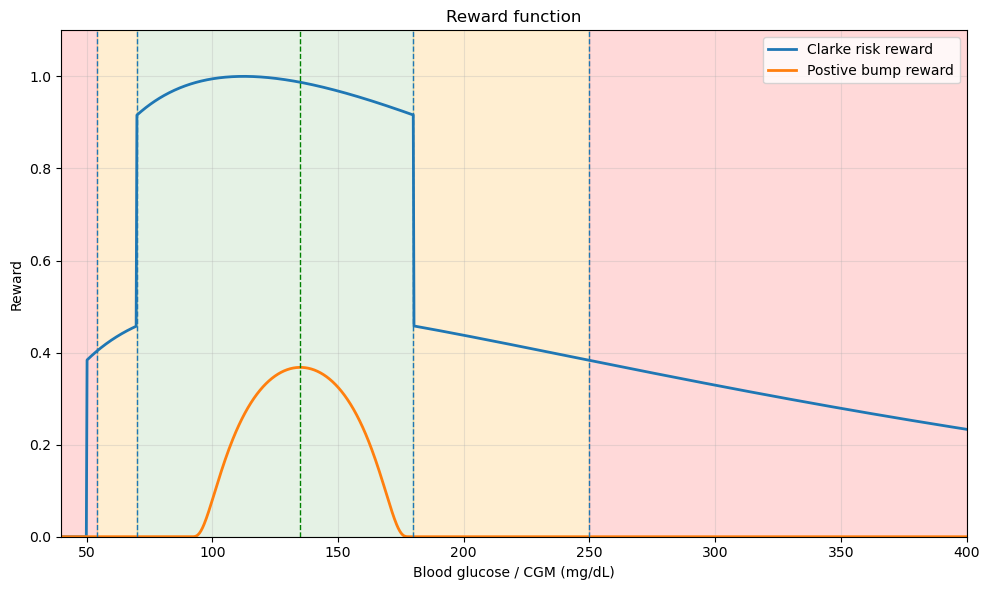

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt


def risk(BG):
    """
    Risk is a percentage - ranging from 0 to 100%.
    """
    MIN_BG = 20.0
    MAX_BG = 600.0

    if BG <= MIN_BG:
        return (100.0, 0.0, 100.0)

    if BG >= MAX_BG:
        return (0.0, 100.0, 100.0)

    U = 1.509 * (np.log(BG) ** 1.084 - 5.381)
    ri = 10 * U**2

    rl, rh = 0.0, 0.0

    if U <= 0:
        rl = ri

    if U >= 0:
        rh = ri

    return (rl, rh, ri)


def glucose_insulin_reward(
    bg: float,
    insulin: float,
    raw_insulin: float,
    max_insulin_action: float = 5.0,
) -> float:
    bg = float(bg)

    _, _, r = risk(bg)

    r1 = (1 - (r / 180)) ** 2

    if 70.0 <= bg <= 180.0:
        return float(r1)

    elif (50.0 <= bg < 70.0) or (bg > 180.0):
        return float(r1 * 0.5)

    return 0.0


def smooth_glucose_insulin_reward(
    bg: float,
    insulin: float,
    raw_insulin: float,
    max_insulin_action: float = 6.0,
) -> float:
    bg = float(bg)

    if 90.0 < bg < 180.0:
        x = (bg - 90.0) / 45.0 - 1.0
        return float(np.exp(-1.0 / (1.0 - x**2)))

    return 0.0


# Plot
bgs = np.linspace(40, 400, 1200)

raw_insulin = 6.0
insulin = min(raw_insulin, 6.0)

risk_rewards = [
    glucose_insulin_reward(
        bg=bg,
        insulin=insulin,
        raw_insulin=raw_insulin,
    )
    for bg in bgs
]

smooth_rewards = [
    smooth_glucose_insulin_reward(
        bg=bg,
        insulin=insulin,
        raw_insulin=raw_insulin,
    )
    for bg in bgs
]

plt.figure(figsize=(10, 6))

plt.plot(
    bgs,
    risk_rewards,
    linewidth=2,
    label="Clarke risk reward",
)

plt.plot(
    bgs,
    smooth_rewards,
    linewidth=2,
    linestyle="-",
    label="Postive bump reward",
)

# Safety regions
plt.axvspan(40, 54, color="red", alpha=0.15)
plt.axvspan(54, 70, color="orange", alpha=0.18)
plt.axvspan(70, 180, color="green", alpha=0.10)
plt.axvspan(180, 250, color="orange", alpha=0.18)
plt.axvspan(250, 400, color="red", alpha=0.15)

for boundary in [54, 70, 180, 250]:
    plt.axvline(boundary, linestyle="--", linewidth=1)

for boundary in [135]:
    plt.axvline(boundary,color="green", linestyle="--", linewidth=1)

plt.title("Reward function")
plt.xlabel("Blood glucose / CGM (mg/dL)")
plt.ylabel("Reward")
plt.xlim(40, 400)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import os 
print(os.getcwd())
os.chdir("../code/SPID_code")

print(os.getcwd())
from gmDAGGER import train_spid

/faststorage/project/GGSpeciale/GGSpeciale/simglucose_singlepatient
/faststorage/project/GGSpeciale/GGSpeciale/code/SPID_code


/home/elisalaegs/miniforge3/envs/thesis/lib/python3.10/site-packages/gym/envs/registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/elisalaegs/miniforge3/envs/thesis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-28 18:47:27.073388: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from stable_baselines3 import PPO
from PySRWrapper import PySRPolicy
from stable_baselines3.common.env_util import make_vec_env


In [5]:
print(os.getcwd())
os.chdir("../../simglucose")

print(os.getcwd())

/faststorage/project/GGSpeciale/GGSpeciale/code/SPID_code
/faststorage/project/GGSpeciale/GGSpeciale/simglucose


In [ ]:
import warnings
from stable_baselines3 import PPO

import gymnasium as gym
import numpy as np
from simglucose_env import make_simglucose_spid_env

from simglucose_env import MultiPatientSimglucoseEnv

environment = lambda: MultiPatientSimglucoseEnv(
    patient_names=[
        "adult#001",
        "adult#002",
        "adult#003",
        "adult#004",
        "adult#005",
    ],
    env_id="simglucose-distill",
    max_episode_steps=480,
    normalize=True,
    scenario_mode="fixed_hb",
    use_custom_reward=True,
)

warnings.filterwarnings(
    "ignore",
    message="You are trying to run PPO on the GPU"
)

warnings.filterwarnings(
    "ignore",
    message="Note: it looks like you are running in Jupyter"
)

# example

# rewards, best_policy, wrapper, run_dir = train_spid(r"/home/ashc/GGSpeciale/ashc_repo/GGSpeciale/code/baseline_code/baseline_models/cartpole/PPO_cartpole.zip", PPO, "", "CartPole-v1", n_iter=1, total_timesteps=3, verbose=2)

teacher_model_path = "output/models/best/best_model.zip"
teacher_model = PPO

rewards, best_policy, wrapper, run_dir = train_spid(teacher_path = teacher_model_path, 
                                                    teacher_model = teacher_model, 
                                                    save_folder_path="distil_results", 
                                                    save_results=True, 
                                                    environment=environment, 
                                                    n_iter=12, 
                                                    total_timesteps=12*1000, 
                                                    n_eval_episodes=10,
                                                    verbose=2)

Loaded local teacher from: output/models/best/best_model.zip
finished collecting trajectories
computing advantages
training
Evaluating trained model
Iteration 0: student reward = -1354.7163 +/- 545.2932
Loaded local teacher from: output/models/best/best_model.zip
finished collecting trajectories
computing advantages
training
Evaluating trained model


In [3]:
student = PySRPolicy.load(r"/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/open_final/clarke_risk/adult-003/best_student_policy.joblib")
best_policy = student
for i, policy in enumerate(best_policy.policy_list):
    print(f"\n=== Action dimension {i} ===")

    sr = policy.sr
    
    best_eq = sr.get_best()["equation"]
    print("\nBest equation:")
    print(best_eq)


=== Action dimension 0 ===

Best equation:
less(x2 + 0.2616911, x0) * 0.16900183


In [1]:
from pathlib import Path



ROOT = Path(
    "/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/open_final/clarke_risk/adult-003"
)

policy_paths = sorted(ROOT.rglob("best_student_policy.joblib"))

print(f"Found {len(policy_paths)} policies\n")

for path in policy_paths:
    # Assumes folder structure: strict/adult-010/best_student_policy.joblib
    patient = path.parent.name

    print("=" * 100)
    print(f"Patient: {patient}")

    try:
        student = PySRPolicy.load(str(path))
    except Exception as exc:
        print(f"FAILED TO LOAD: {exc}")
        continue

    if not hasattr(student, "policy_list"):
        print("Loaded object has no policy_list")
        continue

    for i, policy in enumerate(student.policy_list):
        print(f"\n=== Action dimension {i} ===")

        try:
            sr = policy.sr
            best_eq = sr.get_best()["equation"]
            print("Best equation:")
            print(best_eq)
        except Exception as exc:
            print(f"FAILED TO READ EQUATION: {exc}")

    print()

Found 1 policies

Patient: adult-003
FAILED TO LOAD: name 'PySRPolicy' is not defined


In [4]:
student = PySRPolicy.load(r"/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose/distil_results/best_student_policy.joblib")
best_policy = student
for i, policy in enumerate(best_policy.policy_list):
    print(f"\n=== Action dimension {i} ===")

    sr = policy.sr
    
    best_eq = sr.get_best()["equation"]
    print("\nBest equation:")
    print(best_eq)

Policy loaded

=== Action dimension 0 ===

Best equation:
square(square(square(square(exp(((x0 - (x2 * 2.2867436)) - 0.3107938) - x1)))))


In [ ]:
def evaluate_gm_dagger(
    student_policy,
    teacher_policy,
    env,
    seed=0,
    max_steps=2000,
    gamma=0.99,
    alpha=1e-8,
    eps=1e-8,
    deterministic=True,
):
    """
    Roll out the student policy and compare it to the teacher policy.

    Returns
    -------
    results : dict
        {
            "total_reward": float,
            "mean_performance_loss": float,
            "mean_fidelity_gap": float,
            "mean_gm_dagger_loss": float,
            "rewards": np.ndarray,
            "student_actions": np.ndarray,
            "teacher_actions": np.ndarray,
            "observations": np.ndarray,
            "performance_losses": np.ndarray,
            "fidelity_gaps": np.ndarray,
            "gm_dagger_losses": np.ndarray,
        }
    """

    obs, info = env.reset(seed=seed)

    rewards = []
    observations = []
    student_actions = []
    teacher_actions = []
    next_observations = []

    terminated = False
    truncated = False

    for _ in range(max_steps):
        # Student action: action used in the environment
        student_action, _ = student_policy.predict(obs, deterministic=deterministic)

        # Teacher action: oracle action at the same state
        teacher_action, _ = teacher_policy.predict(obs, deterministic=deterministic)

        student_action = np.asarray(student_action, dtype=np.float32)
        teacher_action = np.asarray(teacher_action, dtype=np.float32)

        # Fix common VecEnv / PySR shapes
        if student_action.ndim == 2 and student_action.shape[0] == 1:
            student_action = student_action[0]
        if teacher_action.ndim == 2 and teacher_action.shape[0] == 1:
            teacher_action = teacher_action[0]

        next_obs, reward, terminated, truncated, info = env.step(student_action)

        observations.append(np.asarray(obs).copy())
        next_observations.append(np.asarray(next_obs).copy())
        student_actions.append(student_action.copy())
        teacher_actions.append(teacher_action.copy())
        rewards.append(float(reward))

        obs = next_obs

        if terminated or truncated:
            break

    observations = np.asarray(observations)
    next_observations = np.asarray(next_observations)
    student_actions = np.asarray(student_actions)
    teacher_actions = np.asarray(teacher_actions)
    rewards = np.asarray(rewards, dtype=np.float32)

    # Fidelity gap: || pi_student(s) - pi_teacher(s) ||^2
    fidelity_gaps = np.sum((student_actions - teacher_actions) ** 2, axis=-1)

    # Performance loss approximation.
    # If you have access to teacher value function, use TD-style advantage.
    performance_losses = compute_teacher_advantage_loss(
        teacher_policy,
        observations,
        student_actions,
        rewards,
        next_observations,
        gamma=gamma,
    )

    # Ensure positive values for geometric mean
    gp = np.abs(performance_losses)# + alpha
    gf = fidelity_gaps# + eps

    gm_dagger_losses = gp * gf

    return {
        "total_reward": float(np.sum(rewards)),
        "mean_performance_loss": float(np.mean(gp)),
        "mean_fidelity_gap": float(np.mean(gf)),
        "mean_gm_dagger_loss": float(np.mean(gm_dagger_losses)),
        "rewards": rewards,
        "student_actions": student_actions,
        "teacher_actions": teacher_actions,
        "observations": observations,
        "performance_losses": gp,
        "fidelity_gaps": gf,
        "gm_dagger_losses": gm_dagger_losses,
    }

import torch


def compute_teacher_advantage_loss(
    teacher,
    states,
    actions,
    rewards,
    next_states,
    gamma=0.99,
):
    """
    Approximate performance loss using the teacher's critic/value function.

    For PPO/TRPO/A2C:
        loss ≈ |r + gamma V(s') - V(s)|

    For SAC/TD3/DDPG:
        loss ≈ |Q(s,a_student) - [r + gamma Q(s', pi_teacher(s'))]|
    """

    device = torch.device("cpu")
    teacher.policy = teacher.policy.to(device)

    states_t = torch.as_tensor(states, dtype=torch.float32, device=device)
    actions_t = torch.as_tensor(actions, dtype=torch.float32, device=device)
    rewards_t = torch.as_tensor(rewards, dtype=torch.float32, device=device).view(-1)
    next_states_t = torch.as_tensor(next_states, dtype=torch.float32, device=device)

    if actions_t.ndim == 1:
        actions_t = actions_t.unsqueeze(-1)

    with torch.no_grad():
        # PPO / TRPO / A2C
        if hasattr(teacher.policy, "predict_values"):
            v_s = teacher.policy.predict_values(states_t).squeeze(-1)
            v_sp = teacher.policy.predict_values(next_states_t).squeeze(-1)

            td_error = rewards_t + gamma * v_sp - v_s
            return np.abs(td_error.cpu().numpy())

        # SAC / TD3 / DDPG
        elif hasattr(teacher.policy, "critic"):
            q_s = teacher.policy.critic.q1_forward(states_t, actions_t).squeeze(-1)

            next_actions_np, _ = teacher.predict(
                next_states,
                deterministic=True,
            )
            next_actions_t = torch.as_tensor(
                next_actions_np,
                dtype=torch.float32,
                device=device,
            )

            if next_actions_t.ndim == 1:
                next_actions_t = next_actions_t.unsqueeze(-1)

            q_sp = teacher.policy.critic.q1_forward(
                next_states_t,
                next_actions_t,
            ).squeeze(-1)

            td_error = q_s - (rewards_t + gamma * q_sp)
            return np.abs(td_error.cpu().numpy())

        else:
            # Fallback: no value/critic available
            return np.abs(rewards - np.mean(rewards))

env = HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=False,
        record=False,
    )
)

#teacher = PPO.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip")
#student = PySRPolicy.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12\best_student_policy.joblib")
#student_stupid = PySRPolicy.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12_no_Q\best_student_policy.joblib")

results = evaluate_gm_dagger(
    student_policy=student_stupid,
    teacher_policy=teacher,
    env=env,
    seed=0,
    max_steps=20000,
)

env.close()

print("Total reward:", results["total_reward"])
print("Performance loss:", results["mean_performance_loss"])
print("Fidelity gap:", results["mean_fidelity_gap"])
print("GM-DAGGER loss:", results["mean_gm_dagger_loss"])

Found 10 patient folders


# adult-001

## Metrics

,value
eval_index,0.000000
TBR_II,4.146101
TBR_I,20.631787
TIR,79.368213
TAR_I,0.000000
TAR_II,0.000000
total_daily_insulin,20.067153
average_insulin,0.066032
critical_failure_rate,100.000000
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

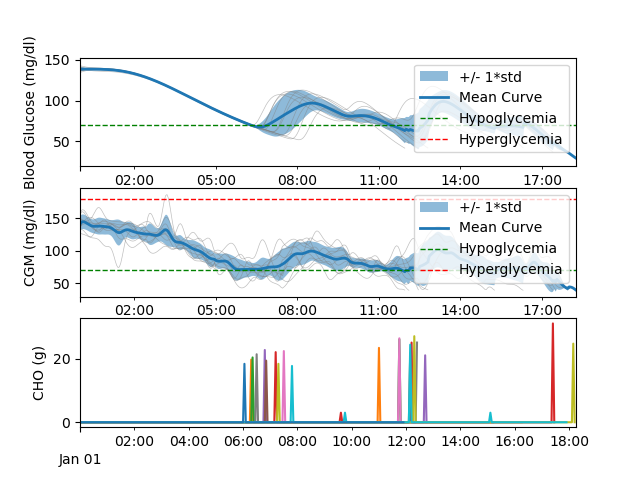

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

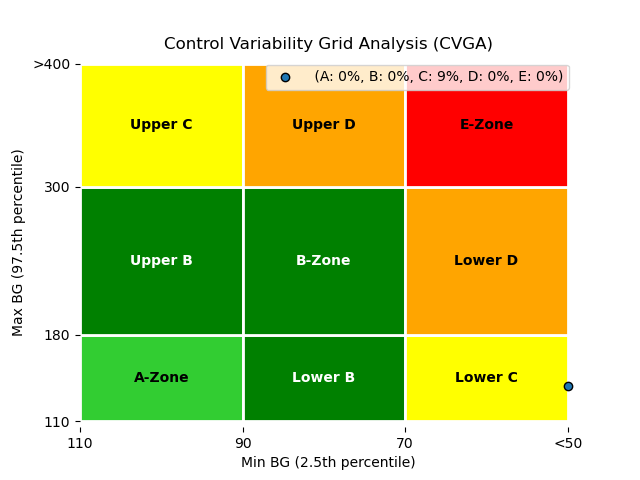

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

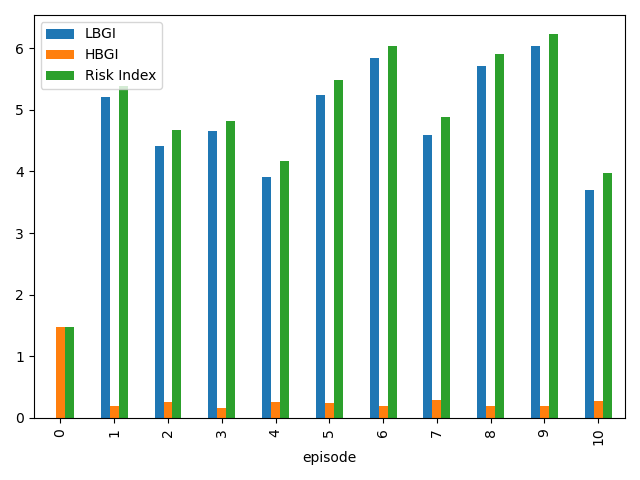

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

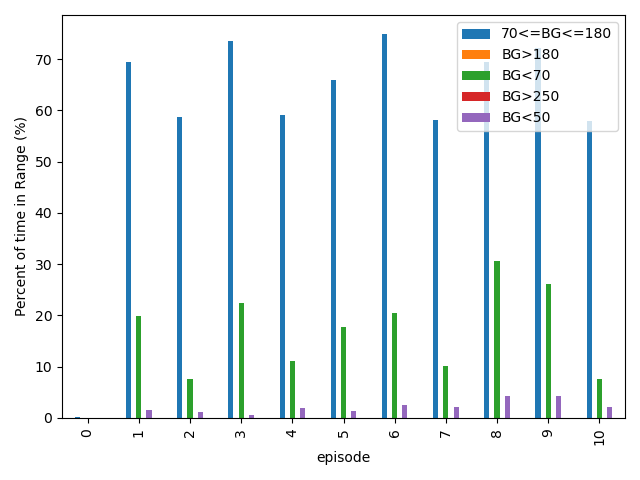

# adult-002

## Metrics

,value
eval_index,0.000000
TBR_II,0.000000
TBR_I,1.375000
TIR,89.333333
TAR_I,9.291667
TAR_II,0.000000
total_daily_insulin,21.056871
average_insulin,0.043868
critical_failure_rate,9.090909
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

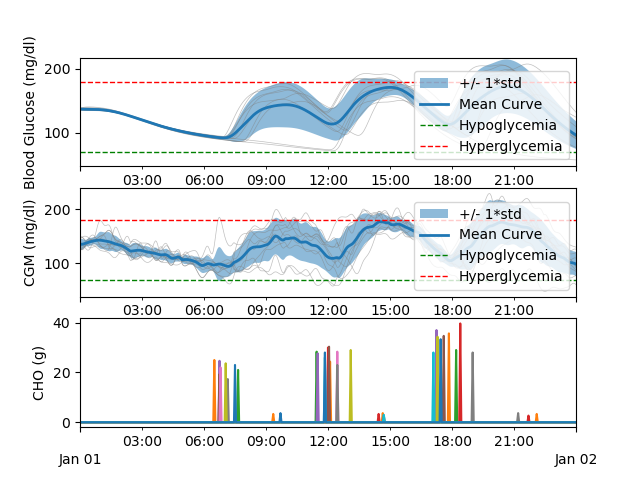

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

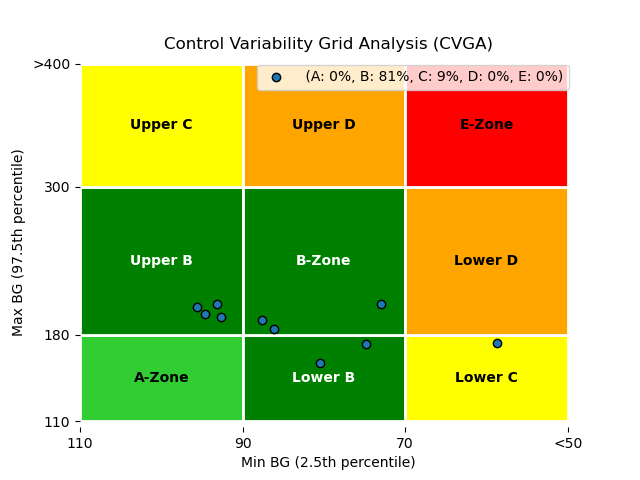

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

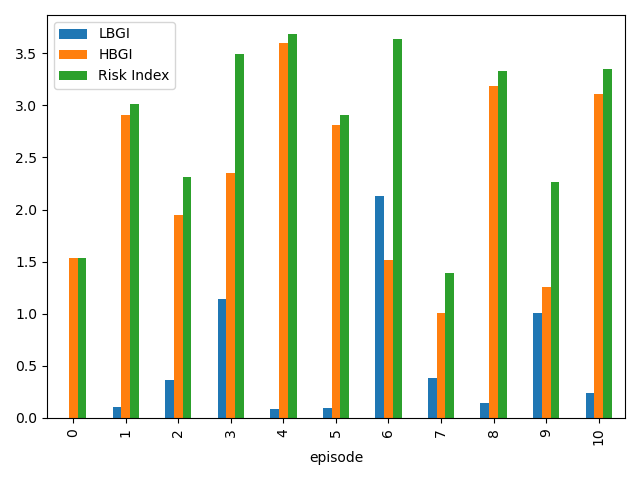

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

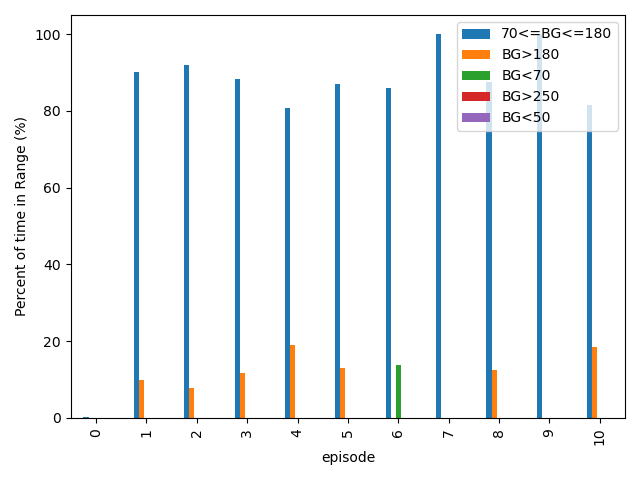

# adult-003

## Metrics

,value
eval_index,0.000000
TBR_II,0.000000
TBR_I,0.000000
TIR,60.541667
TAR_I,39.458333
TAR_II,7.166667
total_daily_insulin,17.151723
average_insulin,0.035733
critical_failure_rate,9.090909
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

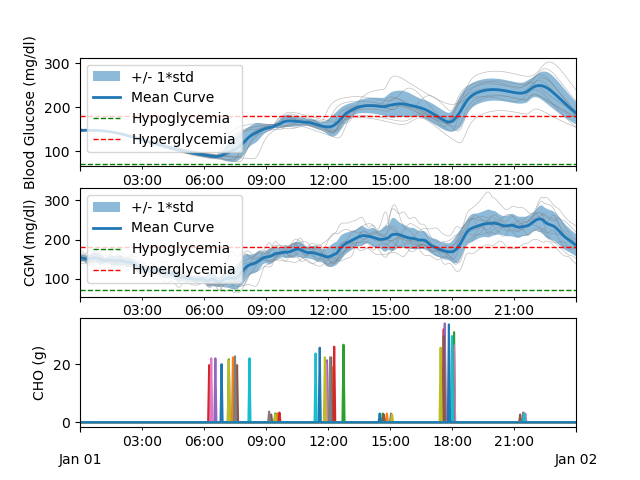

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

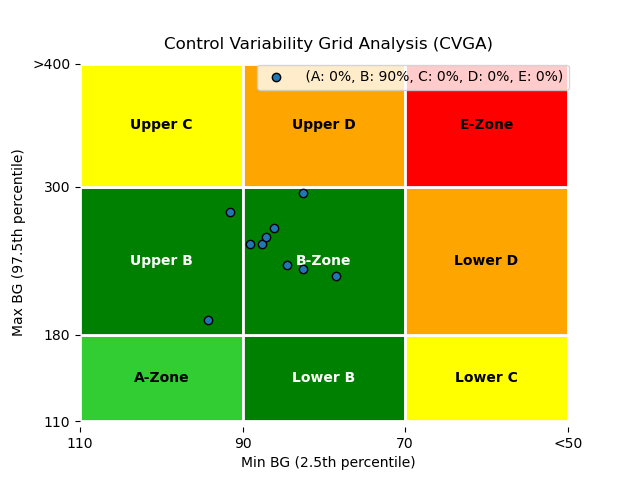

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

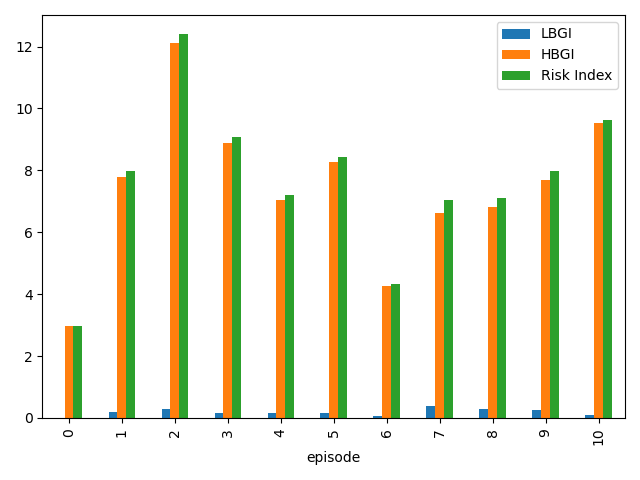

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

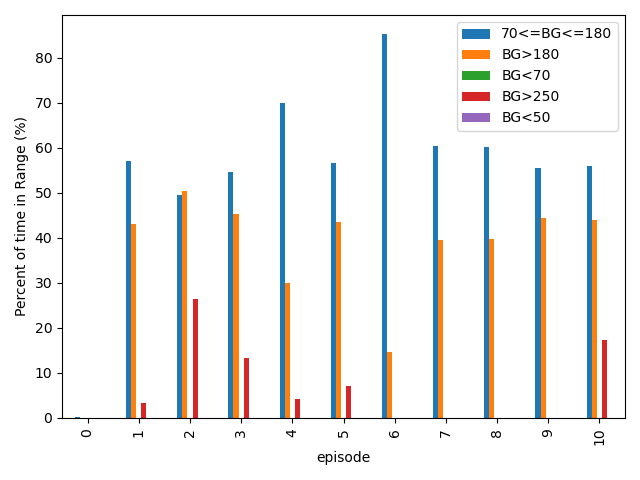

# adult-004

## Metrics

,value
eval_index,0.000000
TBR_II,14.056940
TBR_I,23.487544
TIR,76.512456
TAR_I,0.000000
TAR_II,0.000000
total_daily_insulin,5.266267
average_insulin,0.093706
critical_failure_rate,100.000000
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

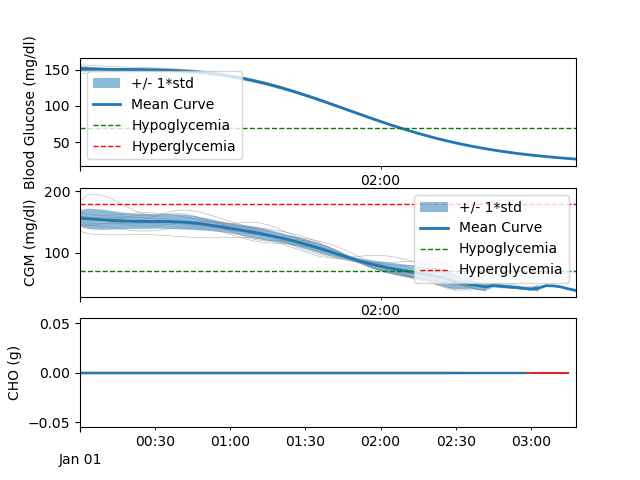

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

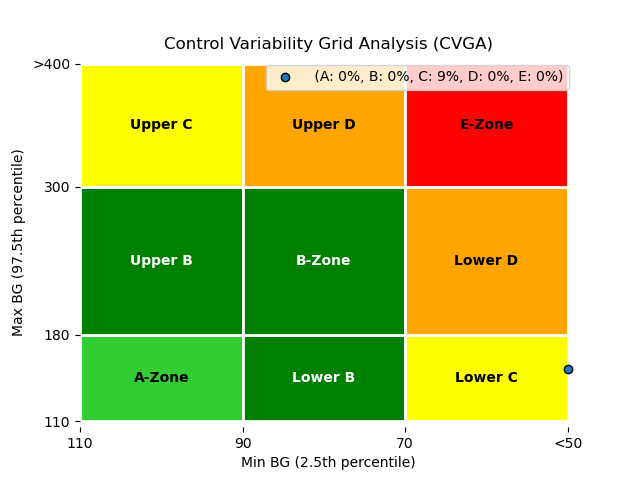

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

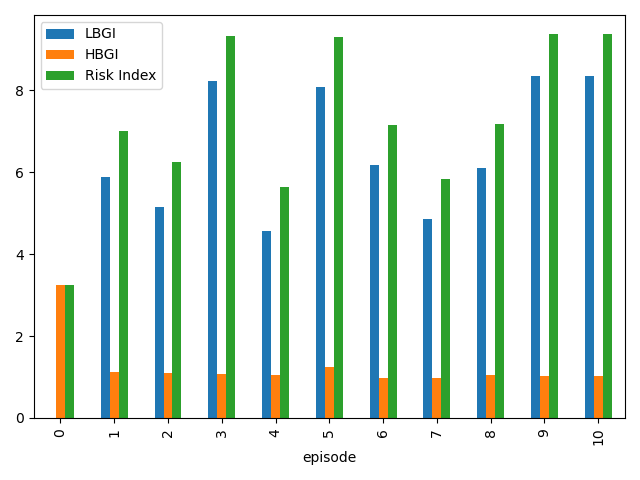

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

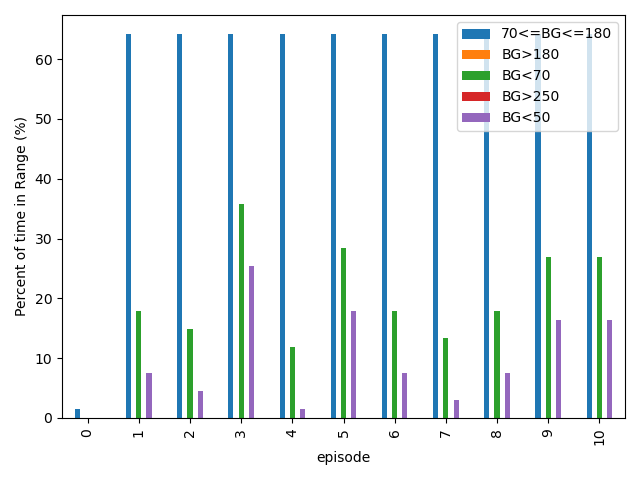

# adult-005

## Metrics

,value
eval_index,0.000000
TBR_II,0.000000
TBR_I,0.000000
TIR,91.270833
TAR_I,8.729167
TAR_II,0.000000
total_daily_insulin,25.753869
average_insulin,0.053654
critical_failure_rate,9.090909
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

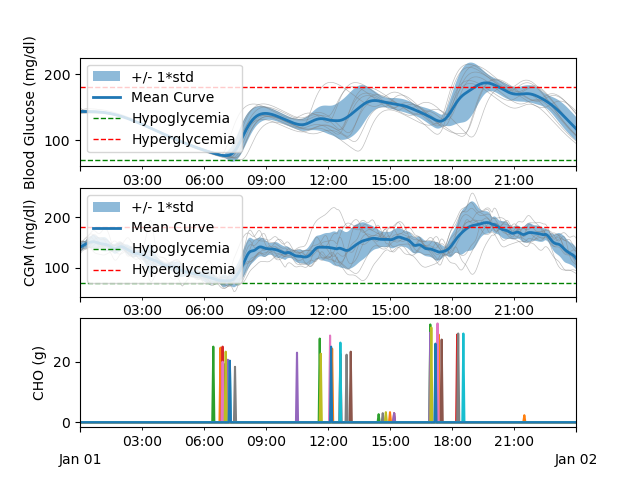

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

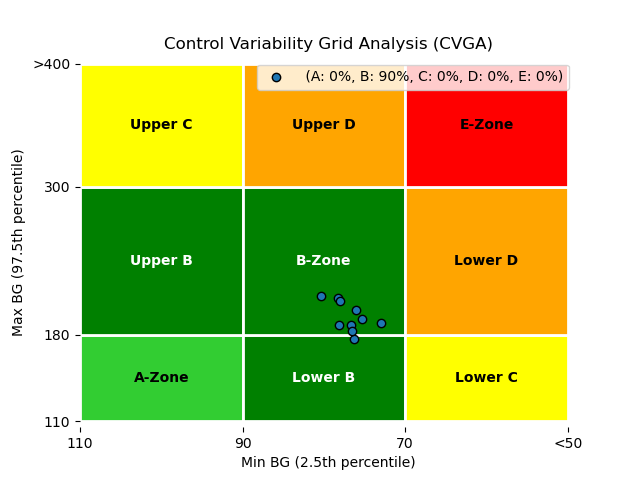

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

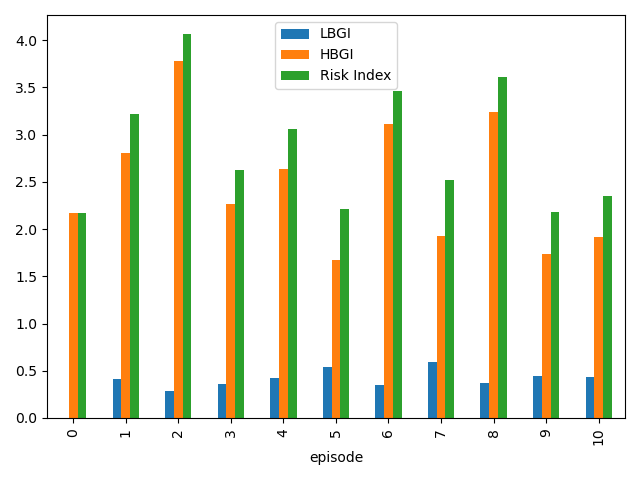

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

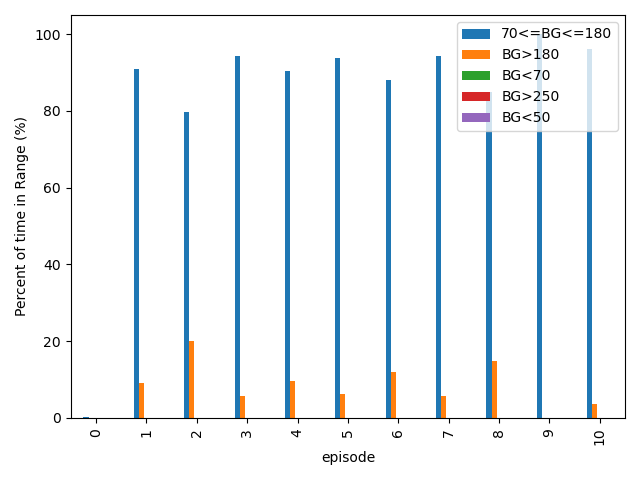

# adult-006

## Metrics

,value
eval_index,0.000000
TBR_II,12.198795
TBR_I,21.234940
TIR,78.765060
TAR_I,0.000000
TAR_II,0.000000
total_daily_insulin,9.878515
average_insulin,0.148773
critical_failure_rate,100.000000
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

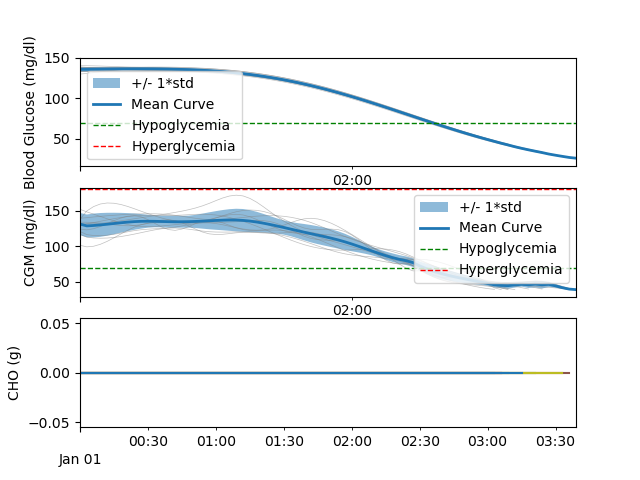

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

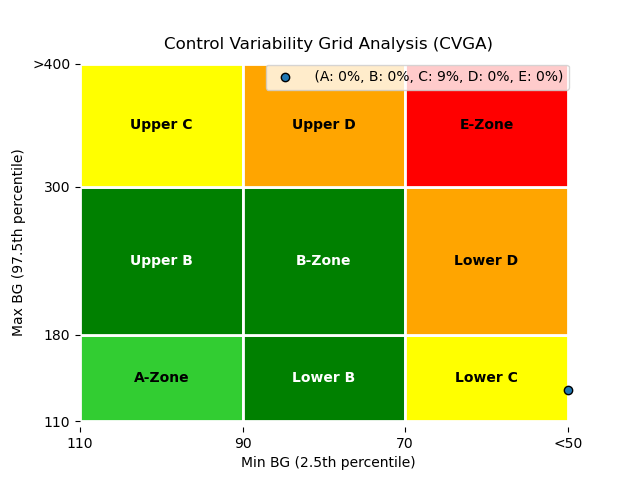

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

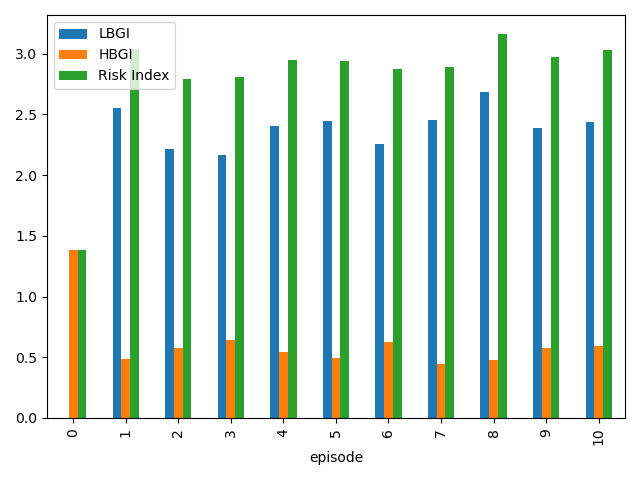

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

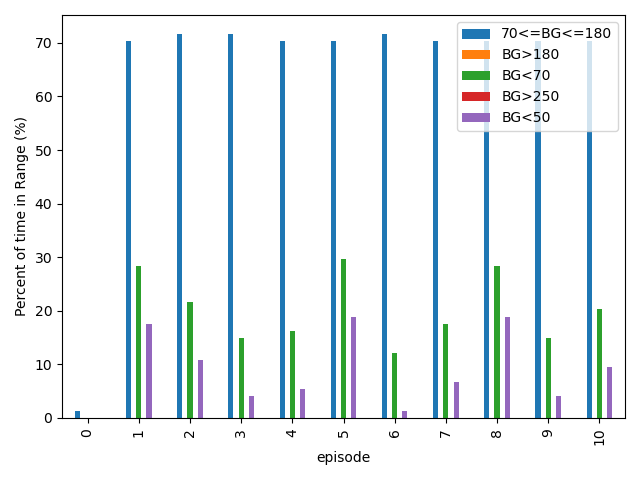

# adult-007

## Metrics

,value
eval_index,0.000000
TBR_II,10.831721
TBR_I,20.696325
TIR,79.303675
TAR_I,0.000000
TAR_II,0.000000
total_daily_insulin,6.047593
average_insulin,0.116975
critical_failure_rate,100.000000
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

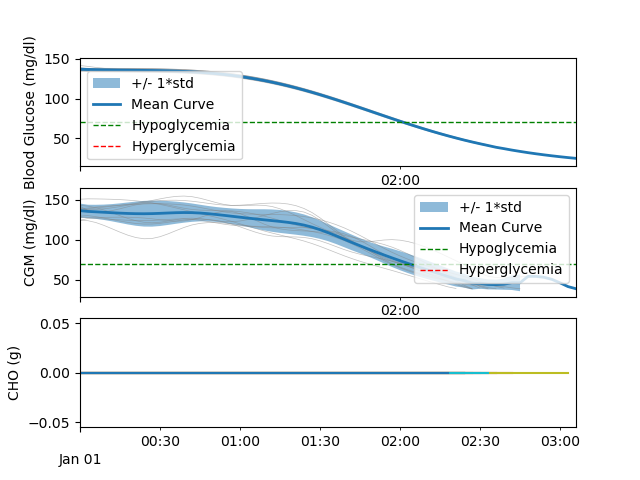

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

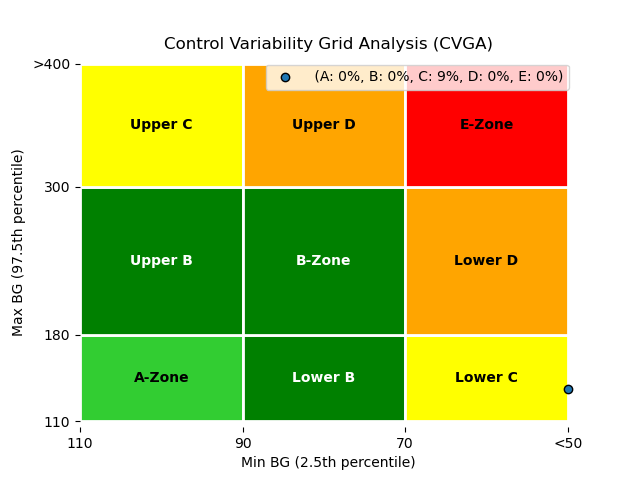

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

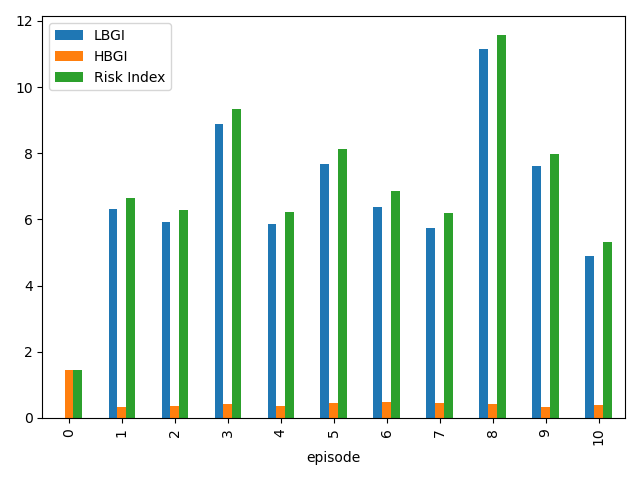

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

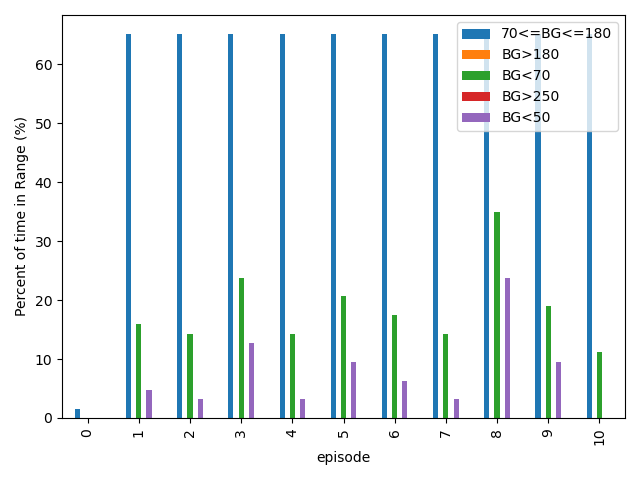

# adult-008

## Metrics

,value
eval_index,0.000000
TBR_II,15.701668
TBR_I,28.164868
TIR,71.835132
TAR_I,0.000000
TAR_II,0.000000
total_daily_insulin,9.198860
average_insulin,0.090273
critical_failure_rate,100.000000
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

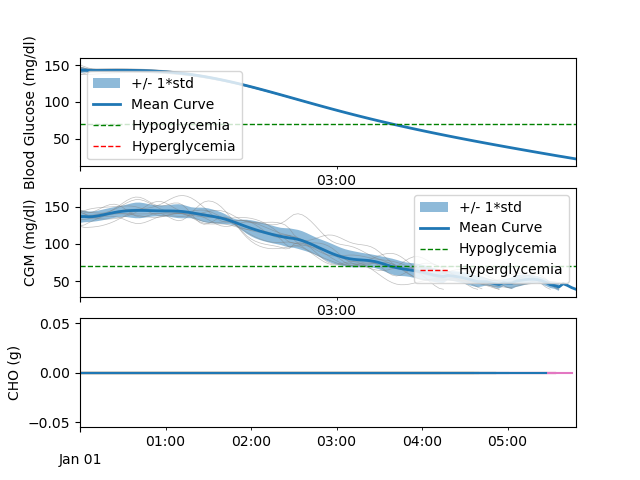

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

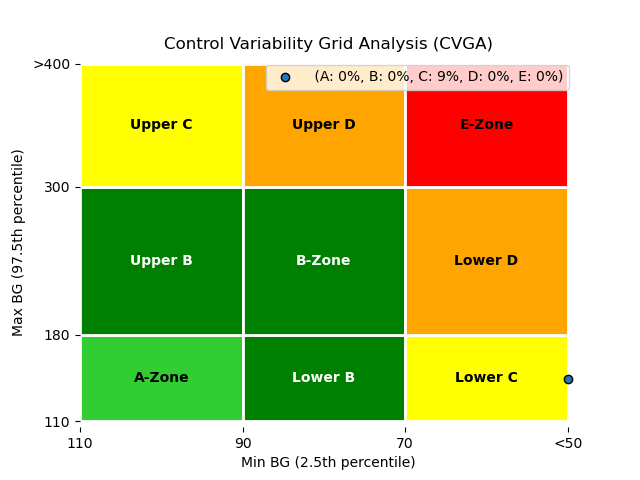

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

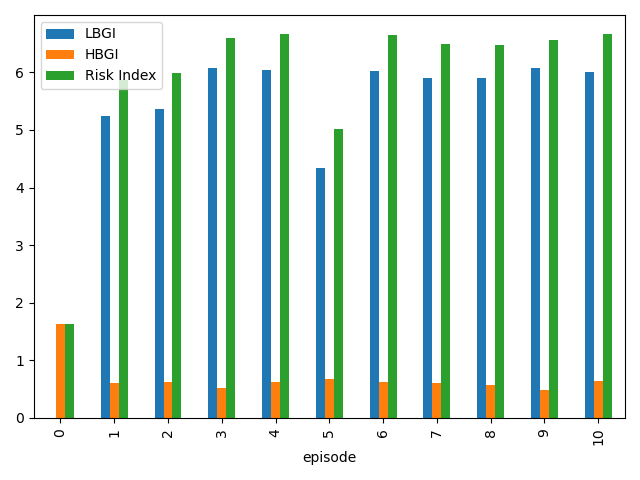

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

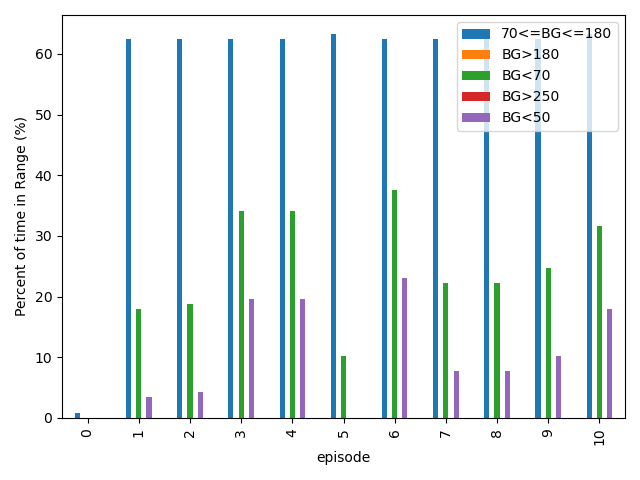

# adult-009

## Metrics

,value
eval_index,0.000000
TBR_II,0.229167
TBR_I,2.145833
TIR,97.854167
TAR_I,0.000000
TAR_II,0.000000
total_daily_insulin,27.560905
average_insulin,0.057419
critical_failure_rate,9.090909
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

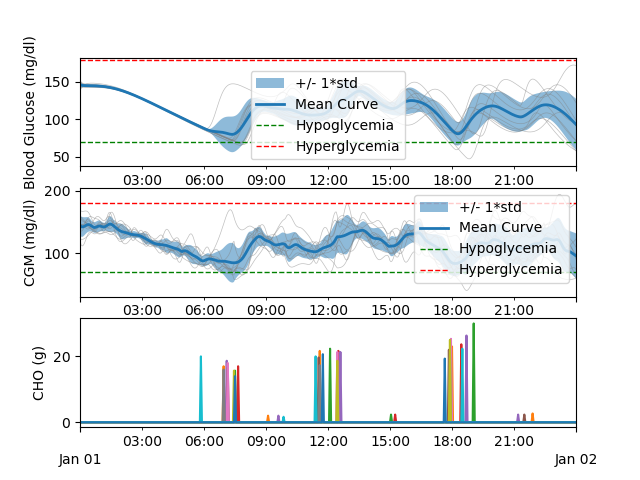

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

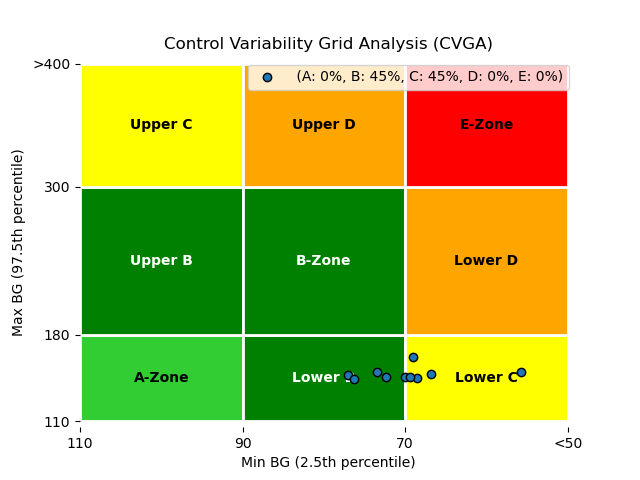

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

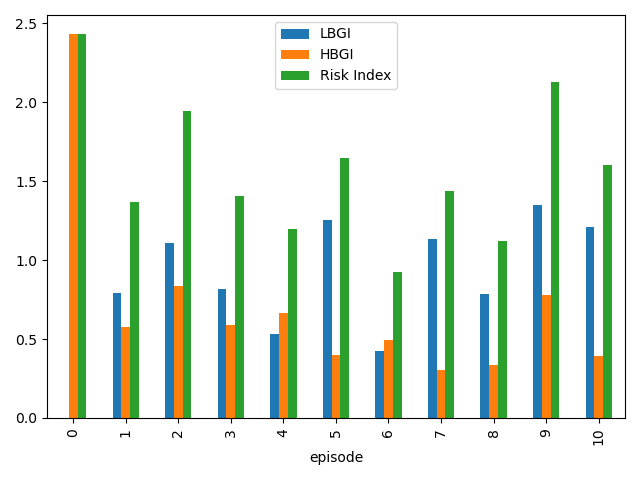

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

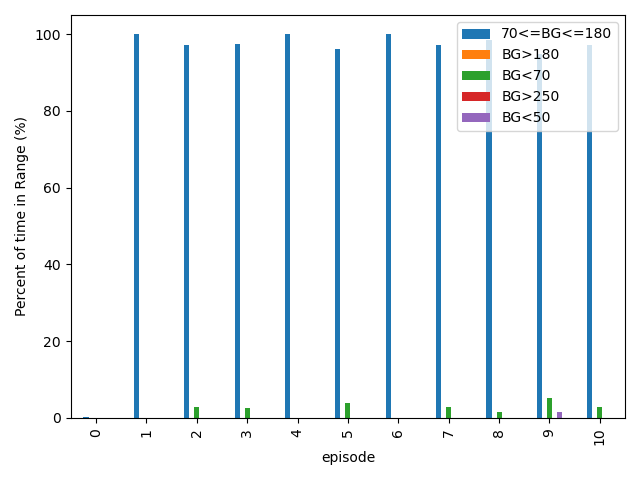

# adult-010

## Metrics

,value
eval_index,0.000000
TBR_II,1.708333
TBR_I,8.041667
TIR,91.958333
TAR_I,0.000000
TAR_II,0.000000
total_daily_insulin,28.722191
average_insulin,0.059838
critical_failure_rate,9.090909
num_timesteps,NaN


## Figures

### `distilled_eval/eval_log/figures/eval_0000/BG_trace.png`

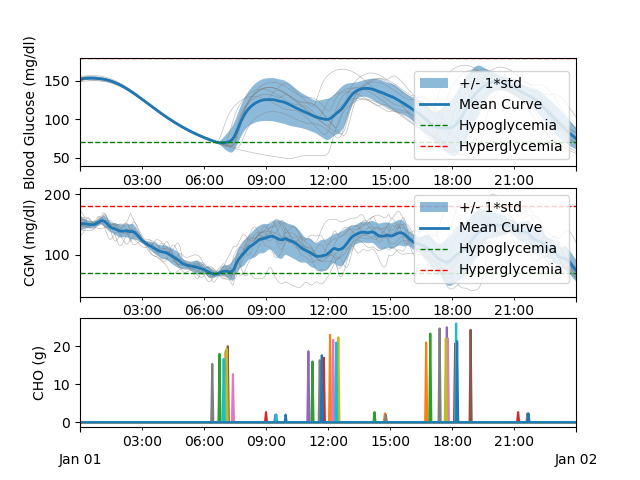

### `distilled_eval/eval_log/figures/eval_0000/CVGA.png`

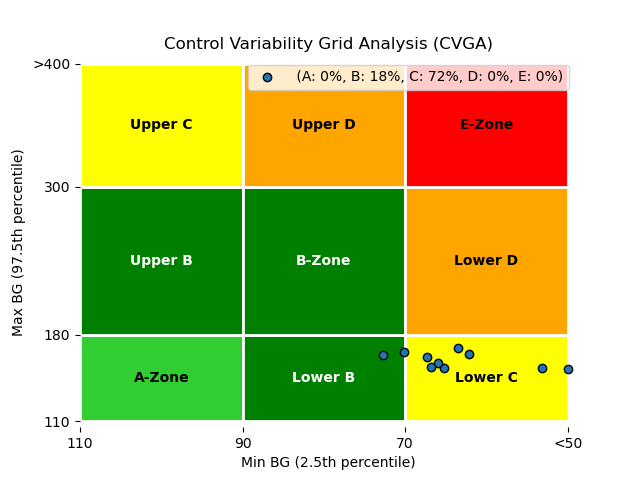

### `distilled_eval/eval_log/figures/eval_0000/risk_stats.png`

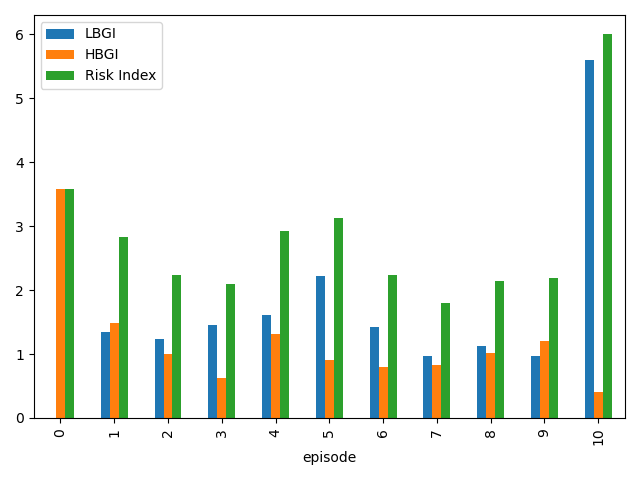

### `distilled_eval/eval_log/figures/eval_0000/zone_stats.png`

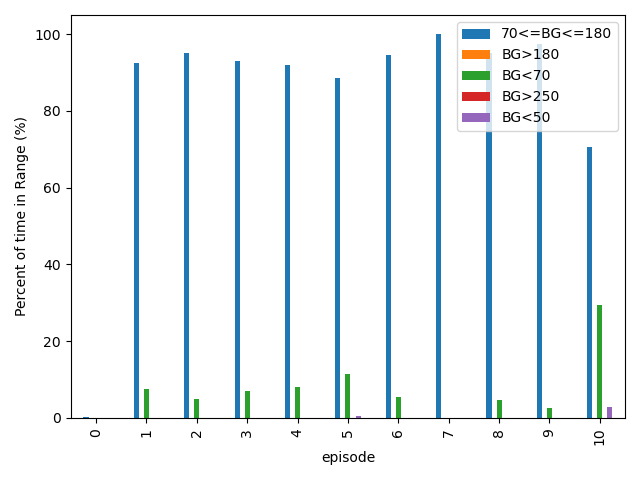

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display, Image, Markdown


ROOT = Path(
    "/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/"
    "distil_benchmark_random/strict"
)

patient_dirs = sorted([p for p in ROOT.glob("adult-*") if p.is_dir()])

print(f"Found {len(patient_dirs)} patient folders")

for patient_dir in patient_dirs:
    patient = patient_dir.name

    eval_log_dir = patient_dir / "distilled_eval" / "eval_log"
    metrics_path = eval_log_dir / "metrics_log.csv"
    figures_root = eval_log_dir / "figures"

    display(Markdown(f"# {patient}"))

    # -------------------------
    # Metrics
    # -------------------------
    if metrics_path.exists():
        metrics_df = pd.read_csv(metrics_path)

        display(Markdown("## Metrics"))

        # Show last row if multiple evaluations were appended
        latest_metrics = metrics_df.tail(1).T
        latest_metrics.columns = ["value"]
        display(latest_metrics)
    else:
        display(Markdown(f"**Missing metrics file:** `{metrics_path}`"))

    # -------------------------
    # PNG figures
    # -------------------------
    png_paths = sorted(figures_root.rglob("*.png"))

    if len(png_paths) == 0:
        display(Markdown(f"**No PNG figures found under:** `{figures_root}`"))
        continue

    display(Markdown("## Figures"))

    for png_path in png_paths:
        rel_name = png_path.relative_to(patient_dir)
        display(Markdown(f"### `{rel_name}`"))
        display(Image(filename=str(png_path)))